In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/chukwuemeka64/mortgage-data/mortgage_loan_dataset.csv


Dataset link :- https://www.kaggle.com/datasets/chukwuemeka64/mortgage-data

In [2]:
data = pd.read_csv("/kaggle/input/datasets/chukwuemeka64/mortgage-data/mortgage_loan_dataset.csv")

# 1. Data Understanding

In [3]:
df = pd.DataFrame(data)
df.head()

,Gender,Age,Married,Education,Job,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Area,Loans Repaid,Max Loan Amount (USD)
0,Male,36,Yes,PhD,Software Engineer,13,134183.86,0.08,101706.78,682,2045.80,Urban,3,498842.67
1,Female,63,No,High School,Freelancer,37,68884.95,0.03,46324.29,823,804.73,Suburban,10,536232.53
2,Female,33,Yes,PhD,Nurse,11,76396.27,0.03,13045.79,813,1050.54,Urban,0,518884.47
3,Female,51,Yes,Bachelor's,Business Owner,29,115968.80,0.05,60388.40,752,904.08,Rural,2,757940.14
4,Male,53,Yes,Bachelor's,Nurse,27,99977.38,0.06,54838.14,728,2285.76,Rural,1,283110.21


In [4]:
df.shape

(49990, 14)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49990 entries, 0 to 49989
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       49990 non-null  object 
 1   Age                          49990 non-null  int64  
 2   Married                      49990 non-null  object 
 3   Education                    49990 non-null  object 
 4   Job                          49990 non-null  object 
 5   Employment Years             49990 non-null  int64  
 6   Annual Income (USD)          49990 non-null  float64
 7   Interest Rate                49990 non-null  float64
 8   Down Payment (USD)           49990 non-null  float64
 9   Credit Score                 49990 non-null  int64  
 10  Existing Monthly Debt (USD)  49990 non-null  float64
 11  Area                         49990 non-null  object 
 12  Loans Repaid                 49990 non-null  int64  
 13  Max Loan Amount 

`Gender` and `Married` column needs to be converted into int

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,49990.0,57.046609,16.947352,28.00,42.0000,57.000,72.0000,86.00
Employment Years,49990.0,32.068234,15.171406,0.00,19.0000,34.000,48.0000,50.00
Annual Income (USD),49990.0,120323.418437,36965.115132,25000.00,95011.1700,119978.225,145455.7850,274740.32
Interest Rate,49990.0,0.050957,0.020815,0.03,0.0300,0.050,0.0600,0.12
Down Payment (USD),49990.0,64296.936887,39594.864102,5000.00,34152.7625,59097.870,87905.0600,250000.00
Credit Score,49990.0,760.373195,63.385441,580.00,717.0000,764.000,811.0000,850.00
Existing Monthly Debt (USD),49990.0,1656.598654,751.032649,0.00,1099.9175,1564.655,2140.2550,5000.00
Loans Repaid,49990.0,5.825545,3.431778,0.00,3.0000,5.000,8.0000,24.00
Max Loan Amount (USD),49990.0,663419.147653,312681.136382,26142.54,425422.7975,623243.470,864104.8875,2270835.80


Checking Spelling

In [9]:
cat_cols = df.select_dtypes(include='object').columns

In [10]:
for col in cat_cols:
    print(f"\n{col}")
    print("Unique values are : ",df[col].unique())
    print("Unique values count : ",df[col].nunique())


Gender
Unique values are :  ['Male' 'Female']
Unique values count :  2

Married
Unique values are :  ['Yes' 'No']
Unique values count :  2

Education
Unique values are :  ['PhD' 'High School' "Bachelor's" "Master's"]
Unique values count :  4

Job
Unique values are :  ['Software Engineer' 'Freelancer' 'Nurse' 'Business Owner' 'Accountant'
 'Banker' 'Teacher' 'Retired' 'Lawyer' 'Doctor' 'Engineer' 'Sales Manager']
Unique values count :  12

Area
Unique values are :  ['Urban' 'Suburban' 'Rural']
Unique values count :  3


In above all the categorical columns contains no speeling error/duplicate values

# 2. Data Cleaning

## 2.1 Convert Categorical Columns to Integer Flags

Convert the `Gender` and `Married` columns into binary integer columns for easier analysis and machine learning.

- **Gender**
  - Male → 1
  - Female → 0
  - New column: `is_male`

- **Married**
  - Yes → 1
  - No → 0
  - New column: `is_married`

In [11]:
# Convert Gender to binary integer column
df["is_male"] = df["Gender"].map({
    "Male": 1,
    "Female": 0
}).astype(int)

In [12]:
# Convert Married to binary integer column
df["is_married"] = df["Married"].map({
    "Yes": 1,
    "No": 0
}).astype(int)

In [13]:
# Drop the original categorical columns
df.drop(columns=["Gender", "Married"], inplace=True)

# Verify the result
df[["is_male", "is_married"]].head()

,is_male,is_married
0,1,1
1,0,0
2,0,1
3,0,1
4,1,1


## 2.2 Converting Float columns to Integer except `Interest Rate`

In [14]:
# Select all float64 columns except "Interest Rate"
float_cols = df.select_dtypes(include="float64").columns.drop("Interest Rate")

# Convert the selected float columns to integers
df[float_cols] = df[float_cols].astype("int64")

# Verify data types
df.dtypes

Age                              int64
Education                       object
Job                             object
Employment Years                 int64
Annual Income (USD)              int64
Interest Rate                  float64
Down Payment (USD)               int64
Credit Score                     int64
Existing Monthly Debt (USD)      int64
Area                            object
Loans Repaid                     int64
Max Loan Amount (USD)            int64
is_male                          int64
is_married                       int64
dtype: object

# 3. EDA

In [15]:
# Numerical columns (excluding binary categorical flags)
num_cols = df.select_dtypes(include=["number"]).columns.drop(['is_male','is_married'])

# Binary columns (better visualized with count plots)
extra_num_cols = ['is_male','is_married']

# Categorical columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns

In [16]:
# Total Numerical Columns
print(f"Total Numerical Columns: {len(num_cols)}")

# Total Extra Numerical Columns
print(f"Total Extra Numerical Columns: {len(extra_num_cols)}")

# Total Categorical Columns
print(f"Total Categorical Columns: {len(cat_cols)}")

Total Numerical Columns: 9
Total Extra Numerical Columns: 2
Total Categorical Columns: 3


## 3.1 Univariate Analysis

### 3.1.1 Numerical Columns

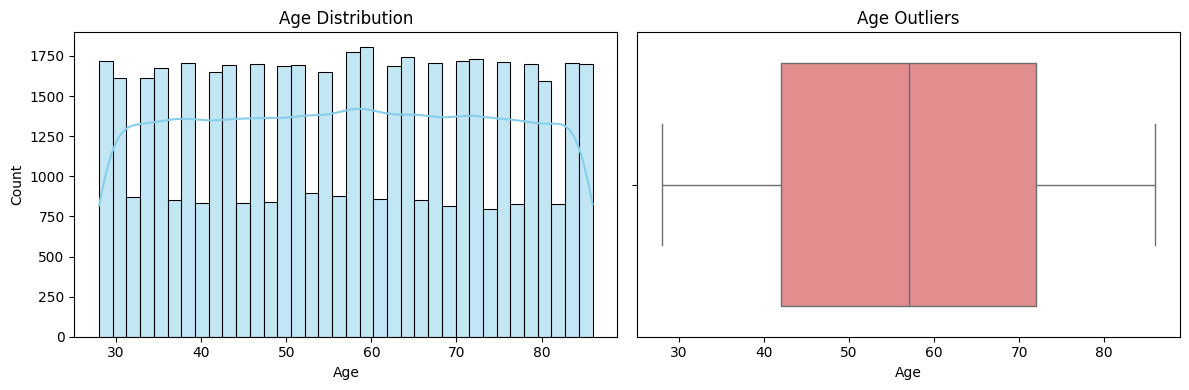

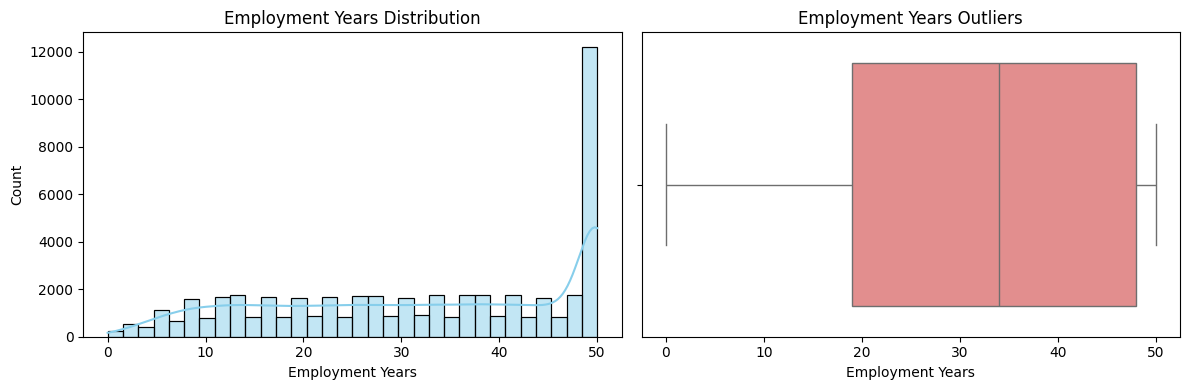

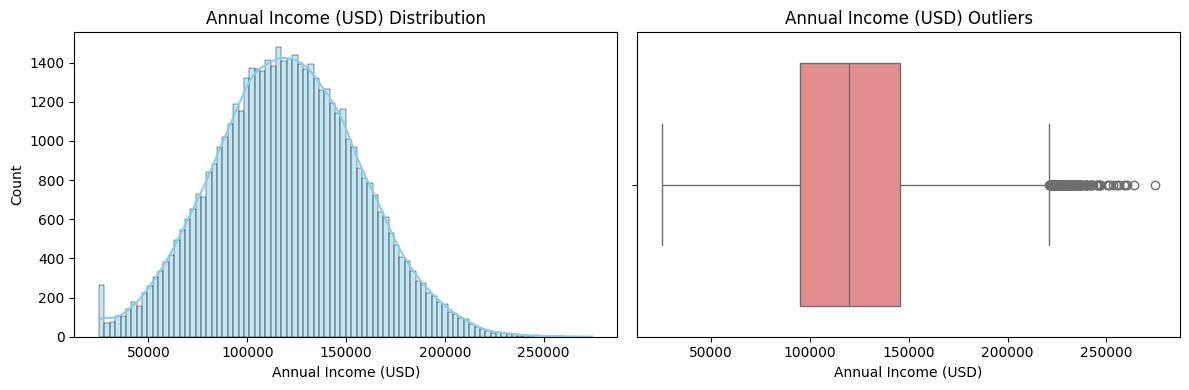

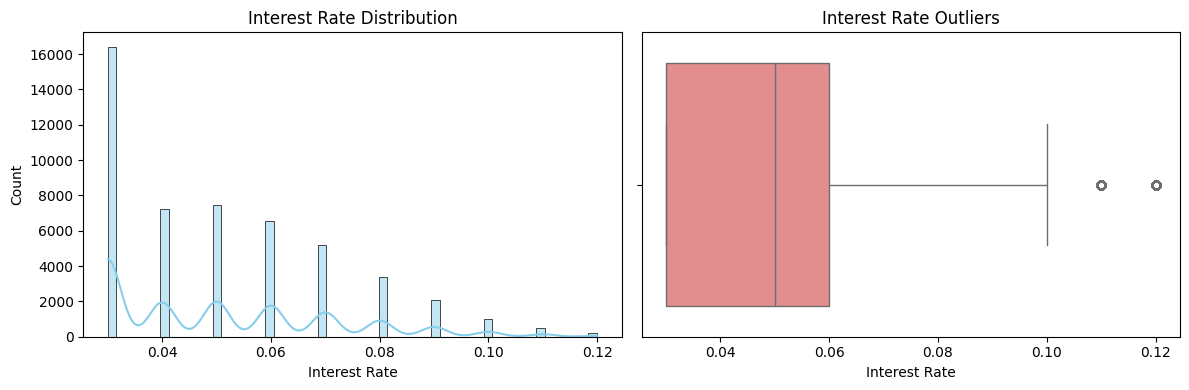

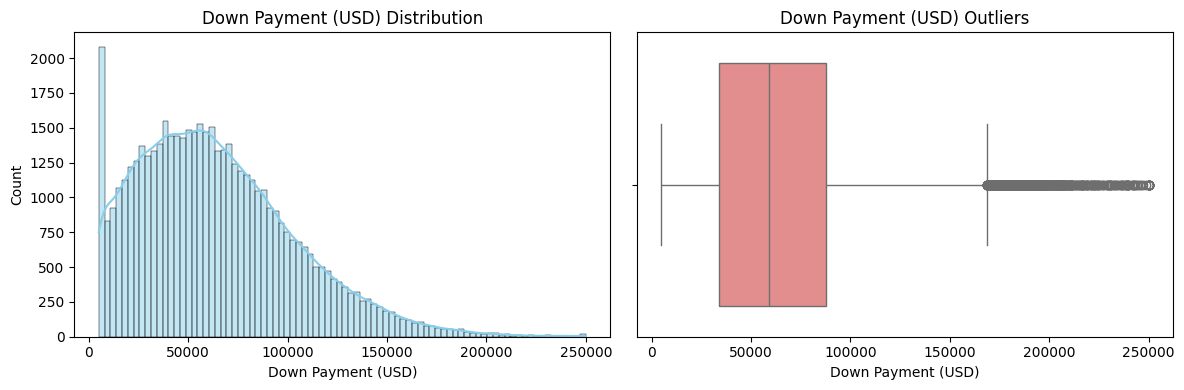

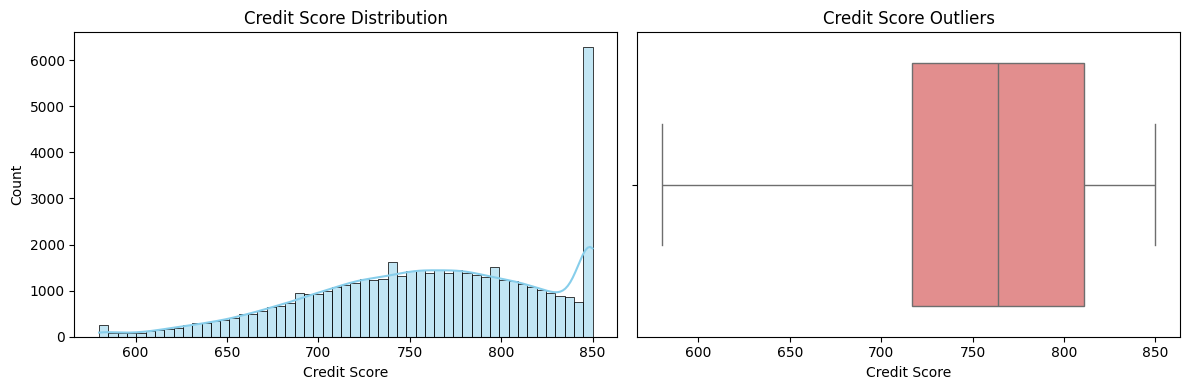

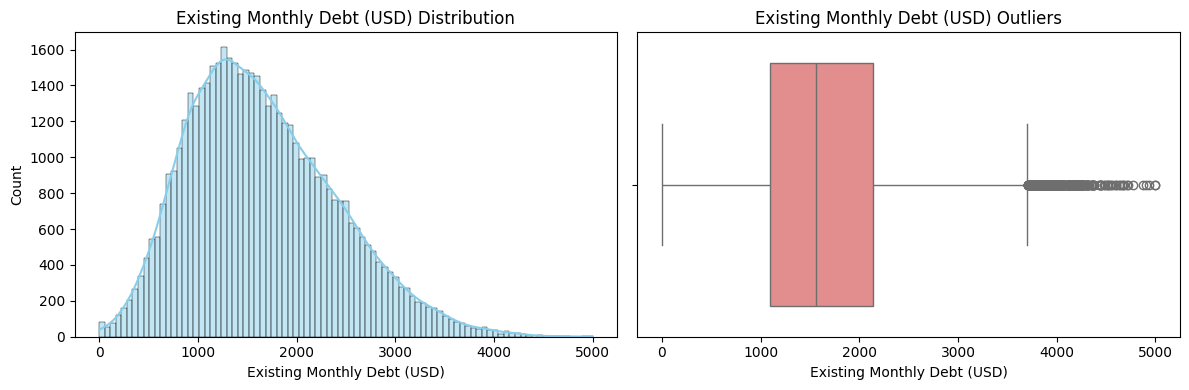

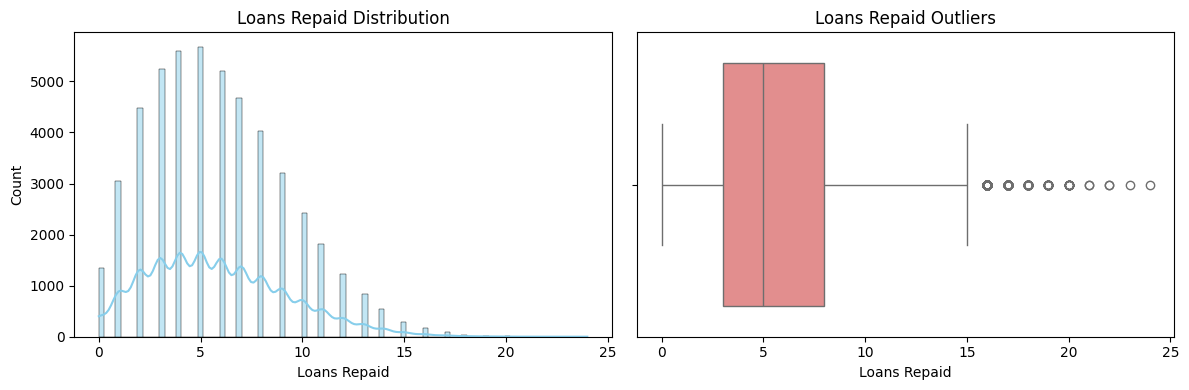

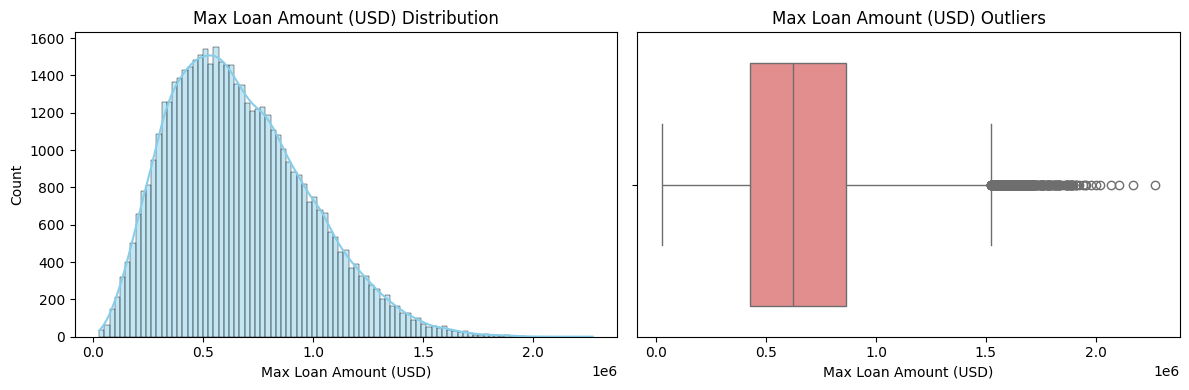

In [17]:
# Plot Histograms and Boxplots side-by-side for each numerical column
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram with KDE curve
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{col} Distribution')
    
    # Boxplot for outliers
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'{col} Outliers')
    
    plt.tight_layout()
    plt.show()

### 3.1.2 Categorical Columns (Count plots)

In [18]:
import math

def count_plot(cols):
    n = len(cols)
    rows = math.ceil(n / 2)

    plt.figure(figsize=(14, 5 * rows))

    for i, col in enumerate(cols, 1):
        plt.subplot(rows, 2, i)

        sns.countplot(
            data=df,
            x=col,
            order=df[col].value_counts().index,
            legend=True
        )

        plt.title(f'{col} Frequency')
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

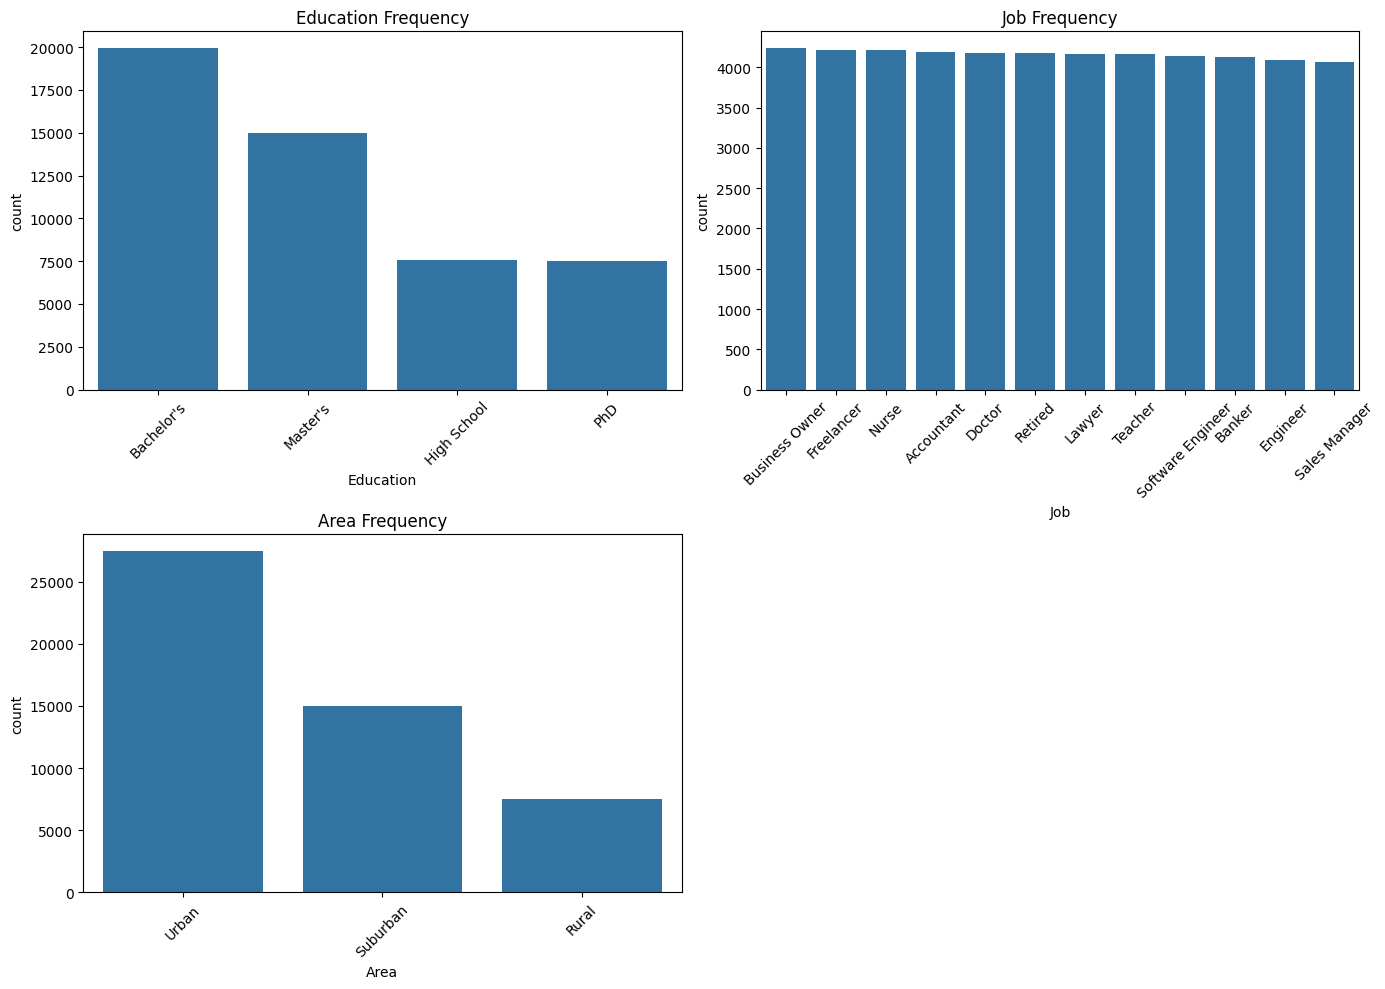

In [19]:
count_plot(cat_cols)

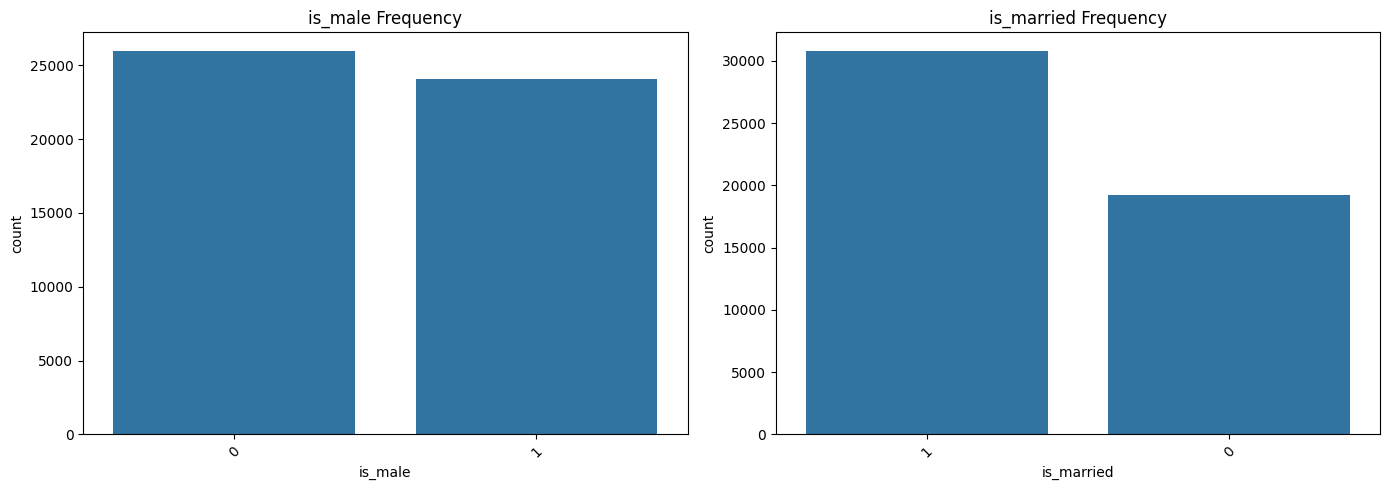

In [20]:
count_plot(extra_num_cols)

`is_male` contains almost equivalent values<br>
`is_married` is little biased towards married

## 3.2 Bivariate Analysis

### 3.2.1 Numerical vs Numerical

#### (a) Correlation Heatmap

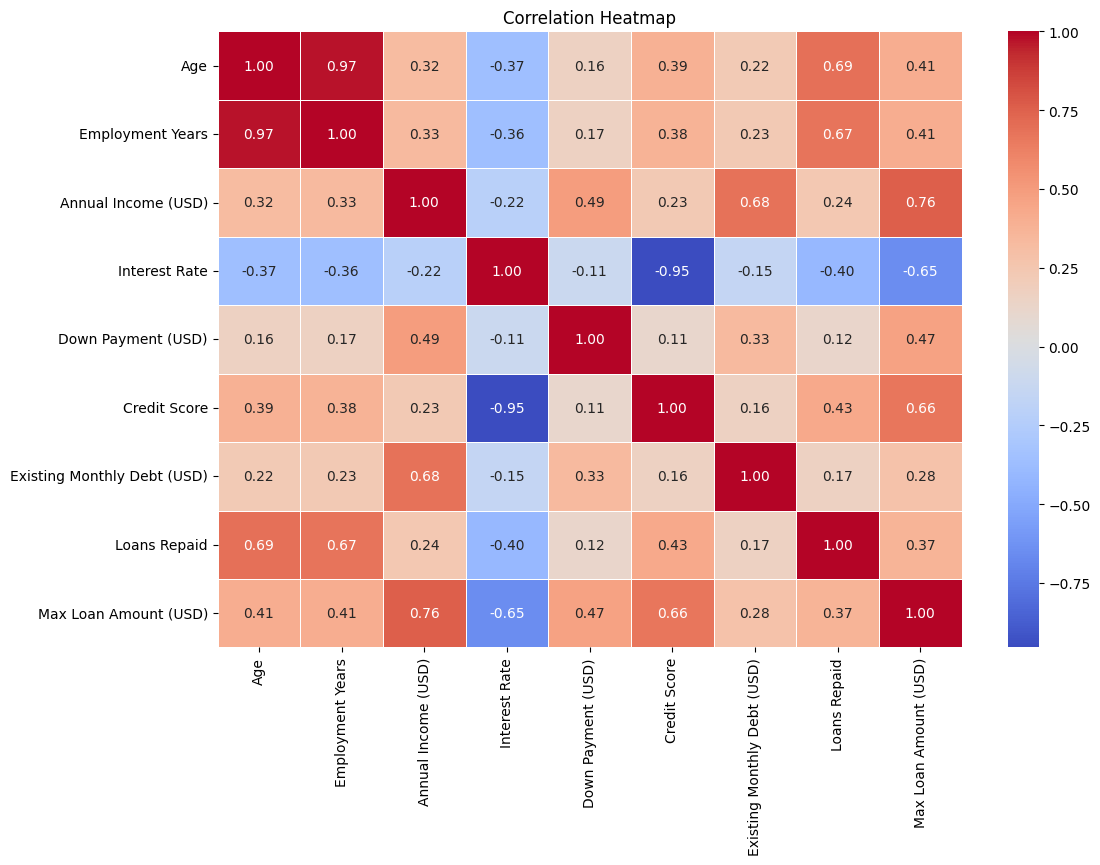

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

#### (b) Pairplot

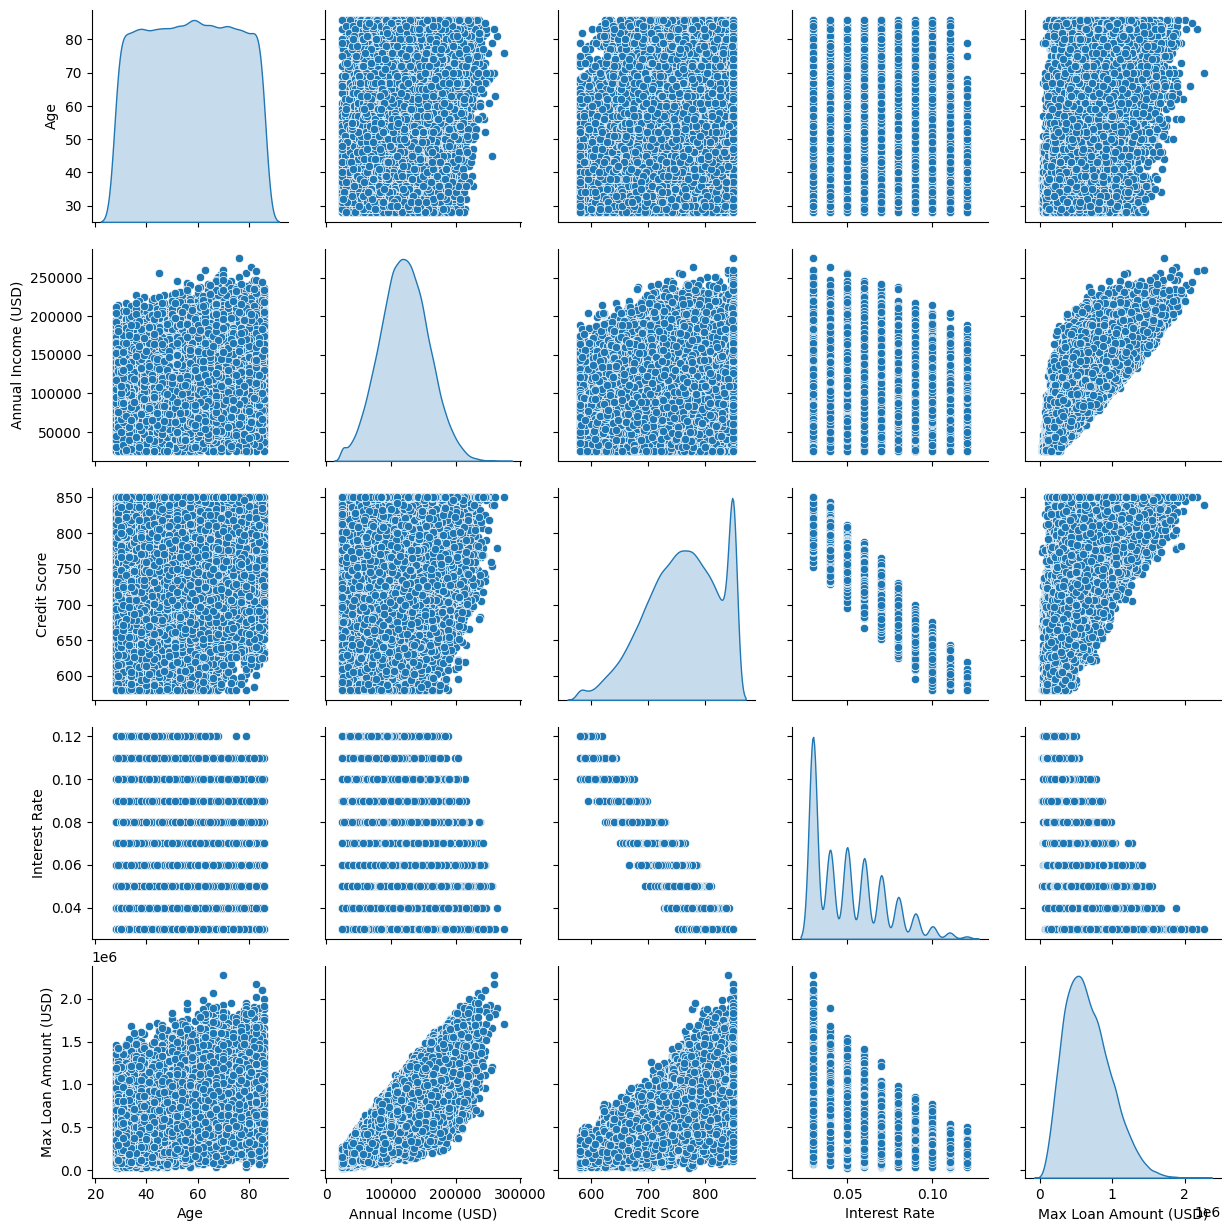

In [22]:
selected = [
    'Age',
    'Annual Income (USD)',
    'Credit Score',
    'Interest Rate',
    'Max Loan Amount (USD)'
]

sns.pairplot(df[selected], diag_kind='kde')
plt.show()

#### (c) Regression Plot

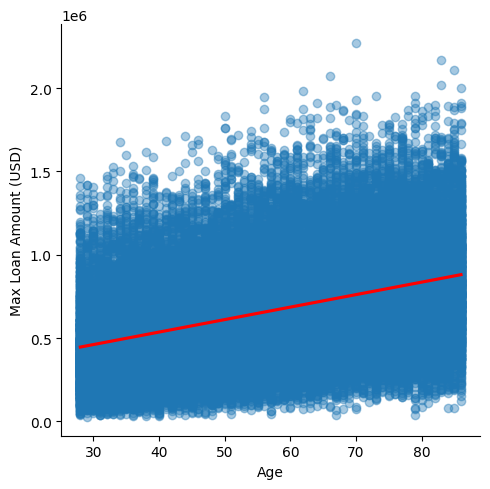

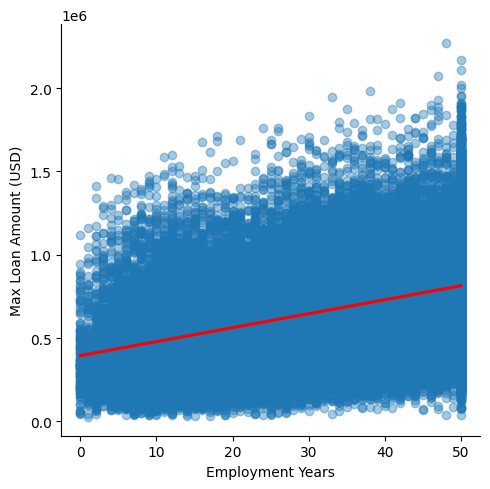

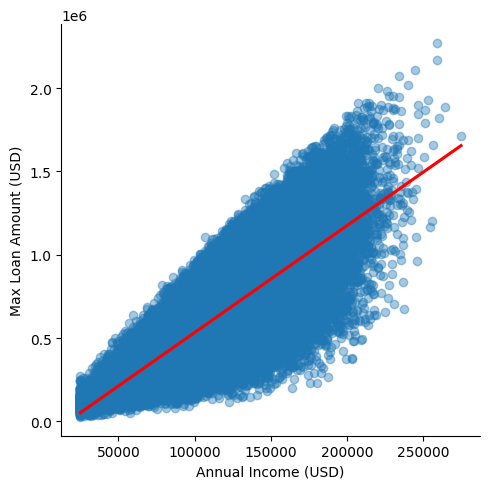

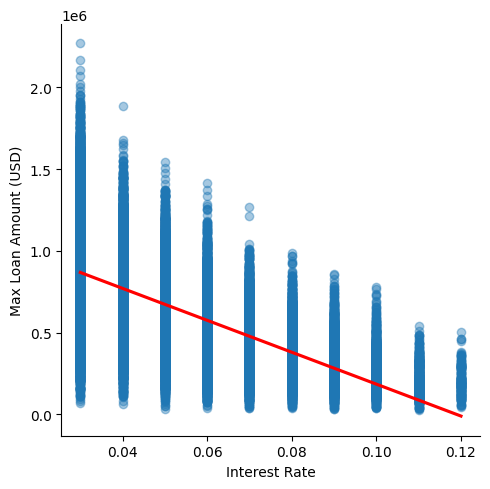

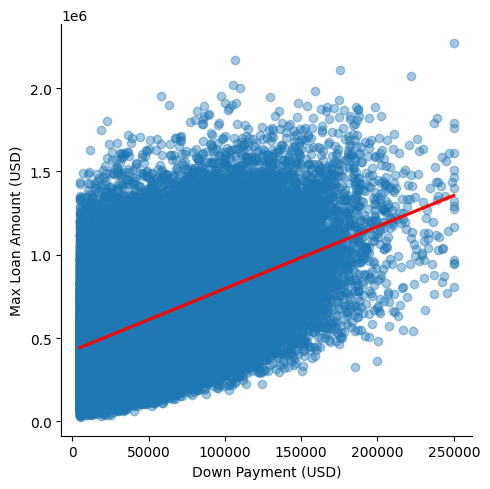

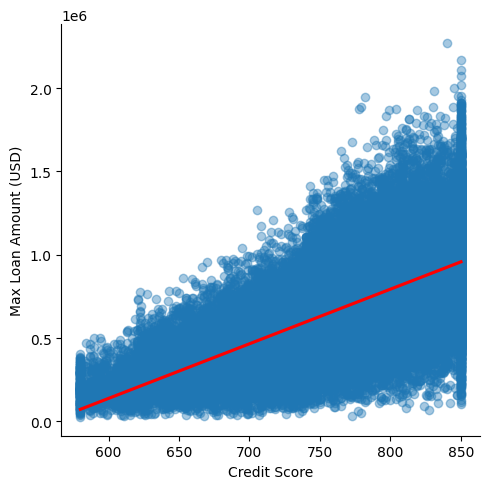

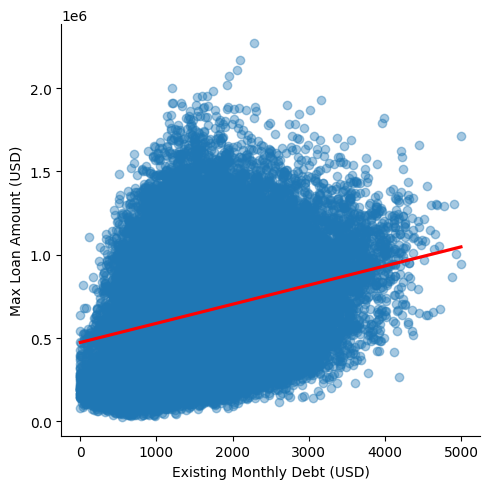

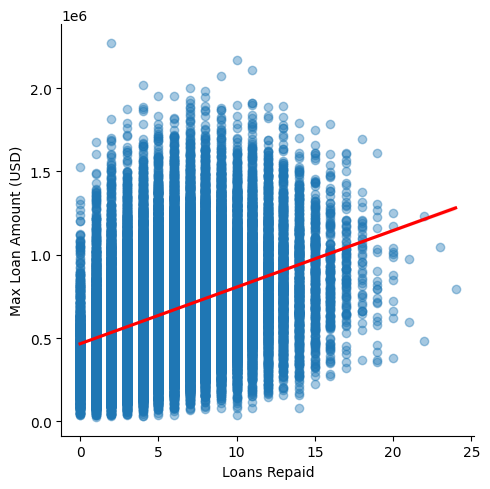

In [23]:
target = "Max Loan Amount (USD)"

for col in num_cols:
    if col != target:
        sns.lmplot(data=df,
                   x=col,
                   y=target,
                   line_kws={'color':'red'},
                   scatter_kws={'alpha':0.4})
        plt.show()

### 3.2.2. Categorical vs Categorical

#### (a) Crosstab

In [24]:
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        print(f"\n{cat_cols[i]} vs {cat_cols[j]}")
        display(pd.crosstab(df[cat_cols[i]], df[cat_cols[j]]))


Education vs Job


Job,Accountant,Banker,Business Owner,Doctor,Engineer,Freelancer,Lawyer,Nurse,Retired,Sales Manager,Software Engineer,Teacher
Education,,,,,,,,,,,,
Bachelor's,1612,1703,1657,1607,1632,1663,1680,1713,1664,1621,1699,1669
High School,675,597,650,616,636,645,640,616,620,629,602,647
Master's,1248,1225,1250,1296,1217,1278,1250,1250,1263,1182,1244,1266
PhD,658,607,678,661,609,631,600,636,630,637,600,581



Education vs Area


Area,Rural,Suburban,Urban
Education,,,
Bachelor's,3042,5945,10933
High School,1120,2248,4205
Master's,2238,4520,8211
PhD,1150,2261,4117



Job vs Area


Area,Rural,Suburban,Urban
Job,,,
Accountant,604,1294,2295
Banker,631,1290,2211
Business Owner,624,1247,2364
Doctor,620,1227,2333
Engineer,635,1222,2237
Freelancer,651,1238,2328
Lawyer,640,1272,2258
Nurse,659,1263,2293
Retired,653,1228,2296


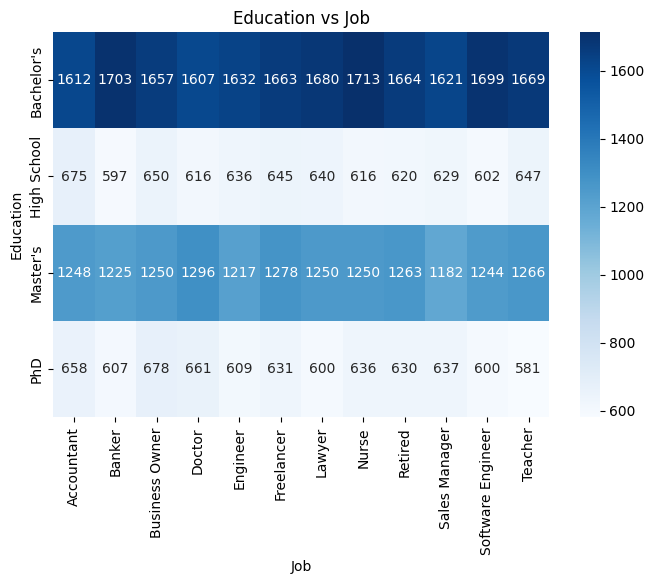

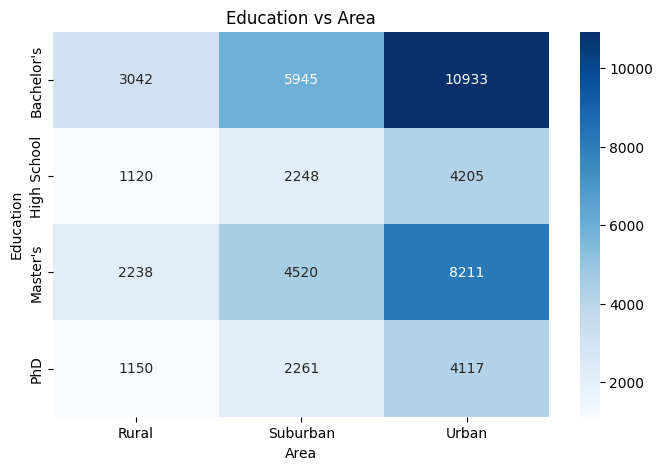

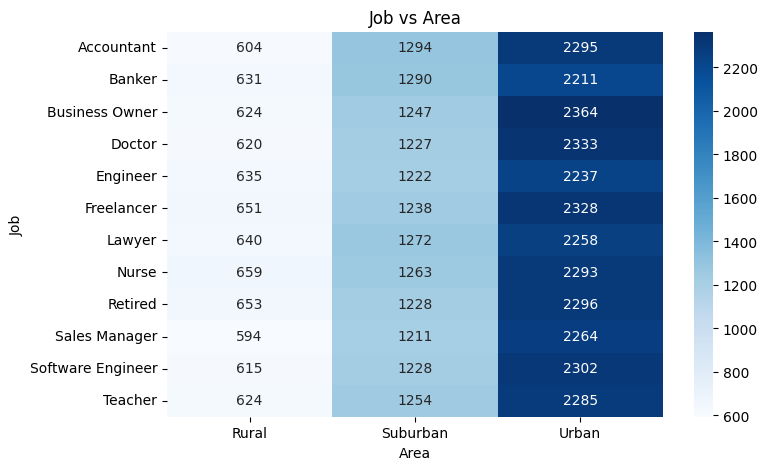

In [25]:
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        ct = pd.crosstab(df[cat_cols[i]], df[cat_cols[j]])

        plt.figure(figsize=(8,5))
        sns.heatmap(ct,
                    annot=True,
                    cmap="Blues",
                    fmt="d")

        plt.title(f"{cat_cols[i]} vs {cat_cols[j]}")
        plt.show()

#### (c) Countplot

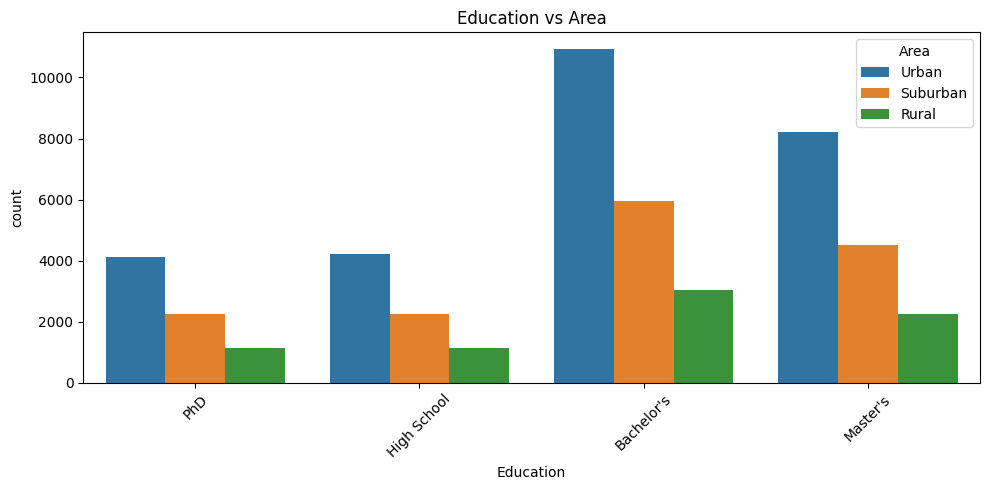

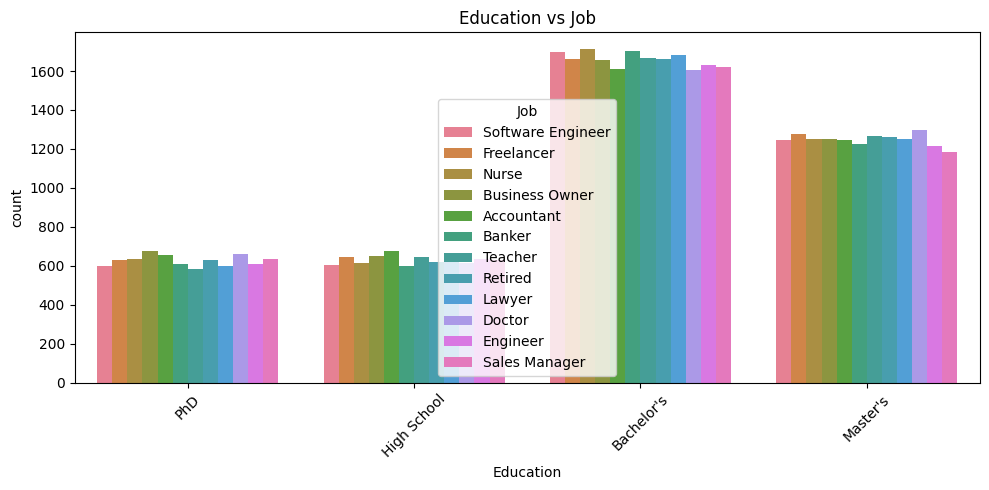

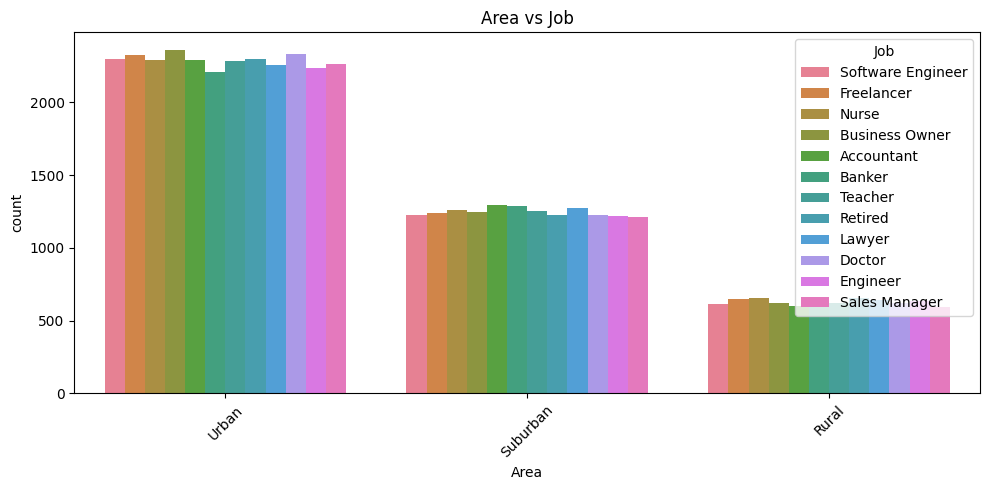

In [26]:
pairs = [
    ('Education', 'Area'),
    ('Education', 'Job'),
    ('Area', 'Job')
]

for x, hue in pairs:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=x, hue=hue)

    plt.title(f"{x} vs {hue}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 3.2.3. Numerical vs Categorical

#### (a) Boxplots

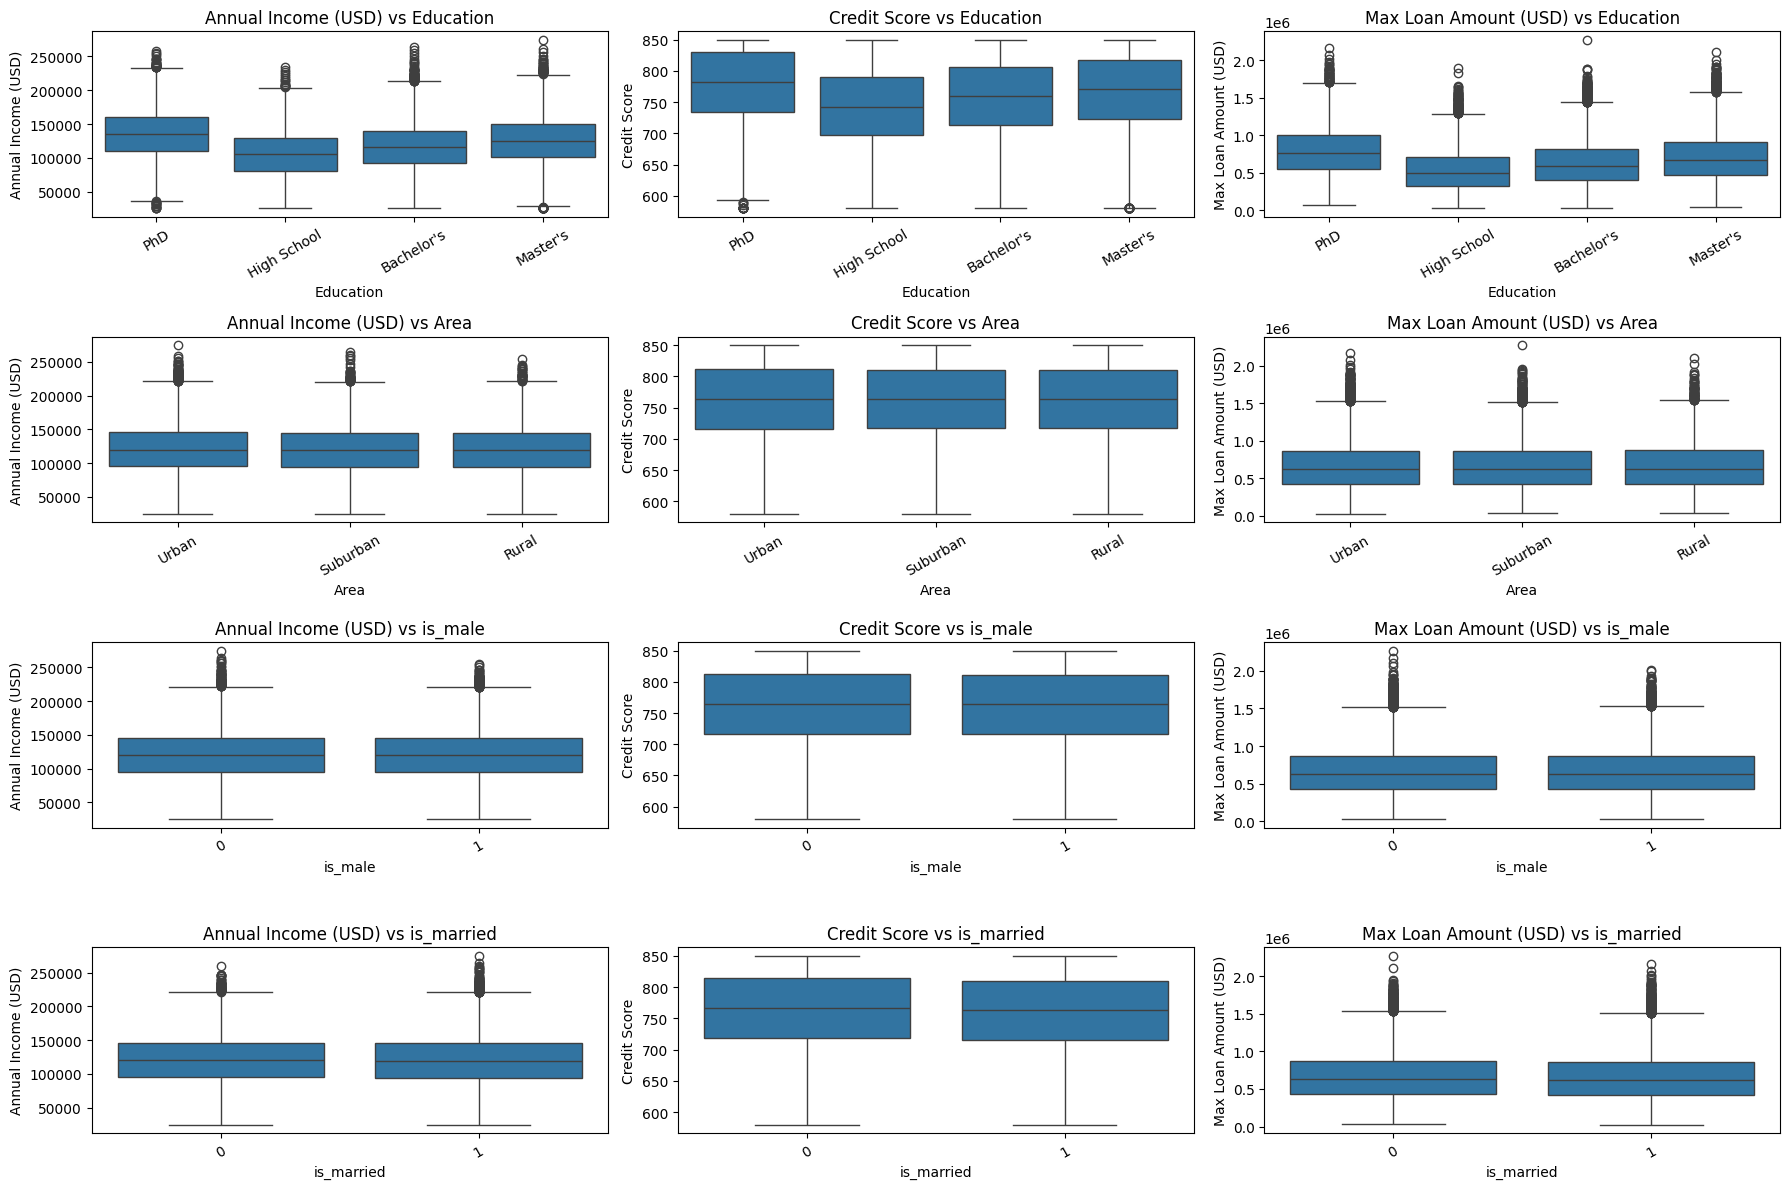

In [27]:
focus_cats = ['Education', 'Area', 'is_male', 'is_married']
focus_nums = ['Annual Income (USD)', 'Credit Score', 'Max Loan Amount (USD)']

fig, axes = plt.subplots(
    len(focus_cats),
    len(focus_nums),
    figsize=(18, 12)
)

for i, cat in enumerate(focus_cats):
    for j, num in enumerate(focus_nums):
        sns.boxplot(
            data=df,
            x=cat,
            y=num,
            ax=axes[i, j]
        )
        axes[i, j].set_title(f"{num} vs {cat}")
        axes[i, j].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

#### (b) Violin Plots

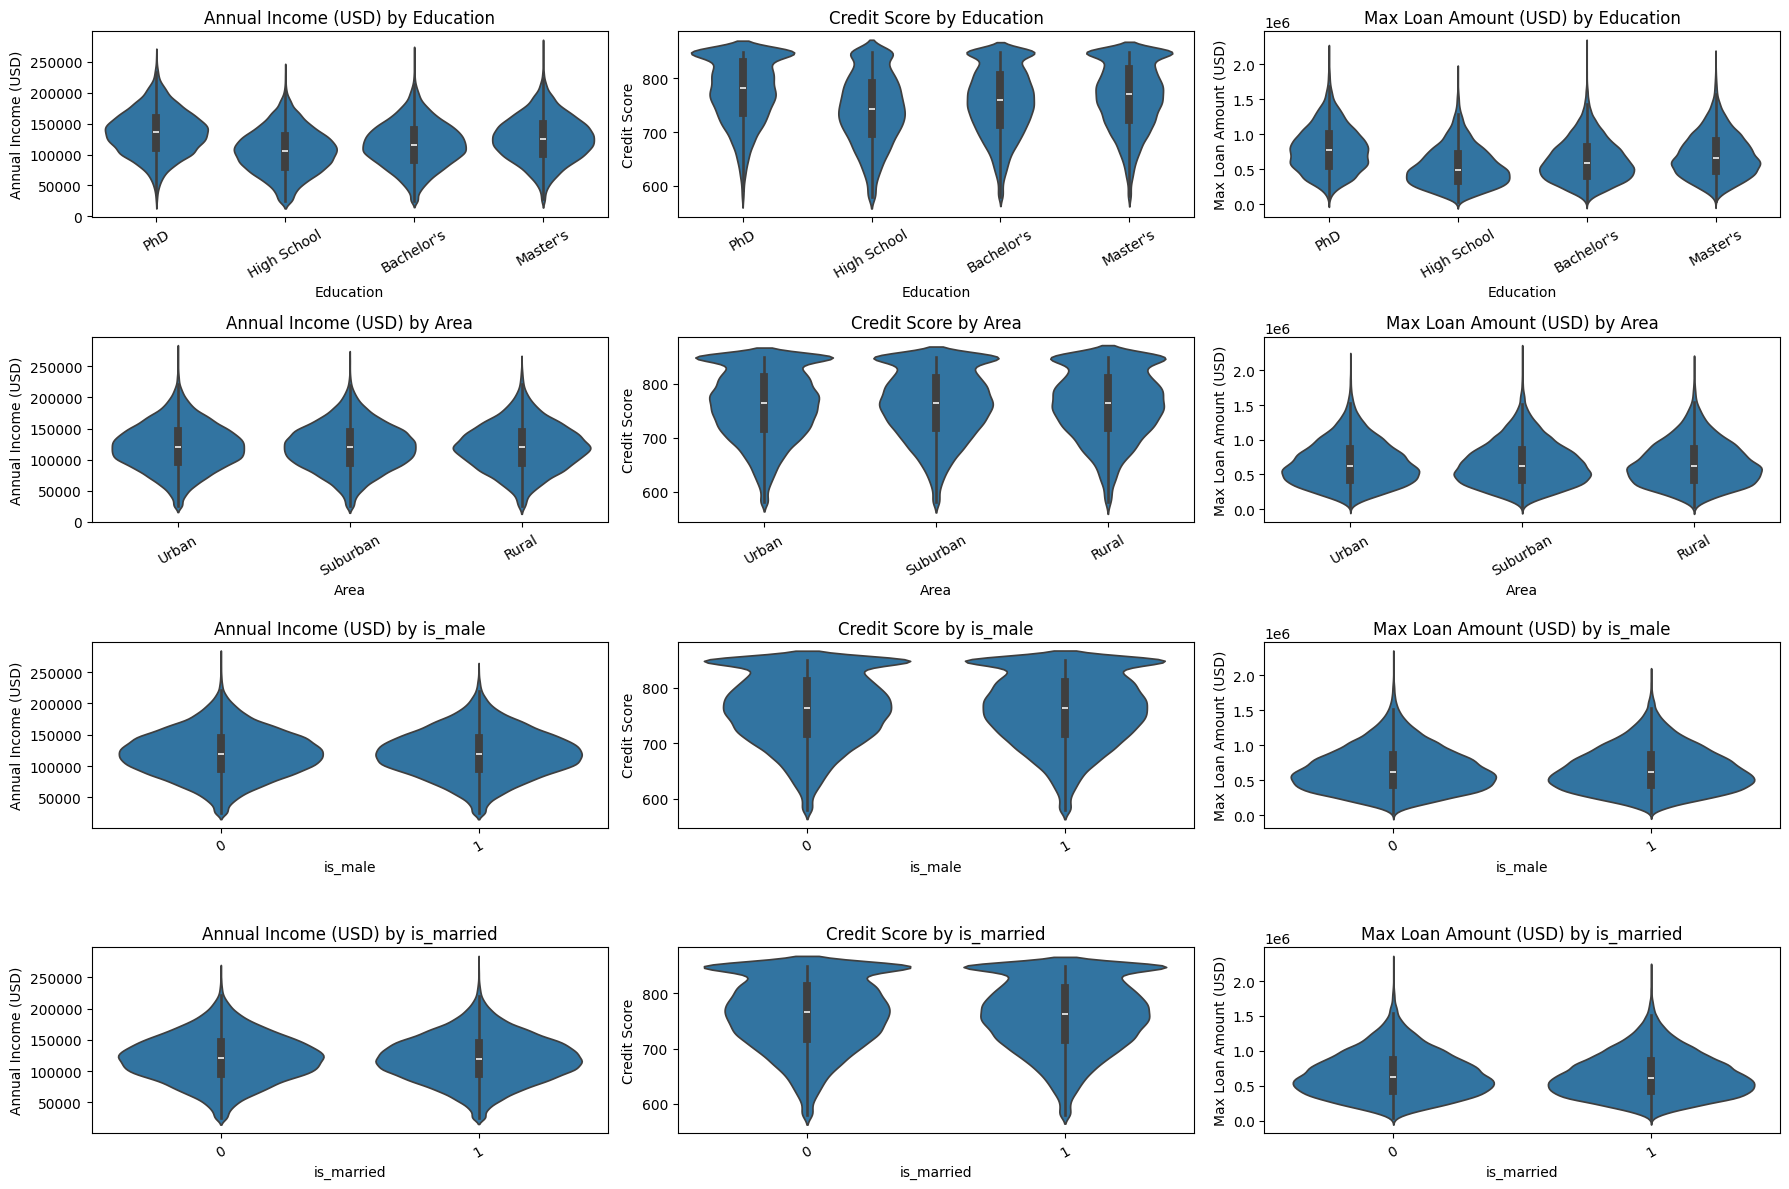

In [28]:
focus_cats = ['Education', 'Area', 'is_male', 'is_married']
focus_nums = ['Annual Income (USD)', 'Credit Score', 'Max Loan Amount (USD)']

fig, axes = plt.subplots(
    len(focus_cats),
    len(focus_nums),
    figsize=(18, 12)
)

for i, cat in enumerate(focus_cats):
    for j, num in enumerate(focus_nums):
        sns.violinplot(
            data=df,
            x=cat,
            y=num,
            ax=axes[i, j]
        )
        axes[i, j].set_title(f"{num} by {cat}")
        axes[i, j].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

#### (c) Barplot (Mean Values)

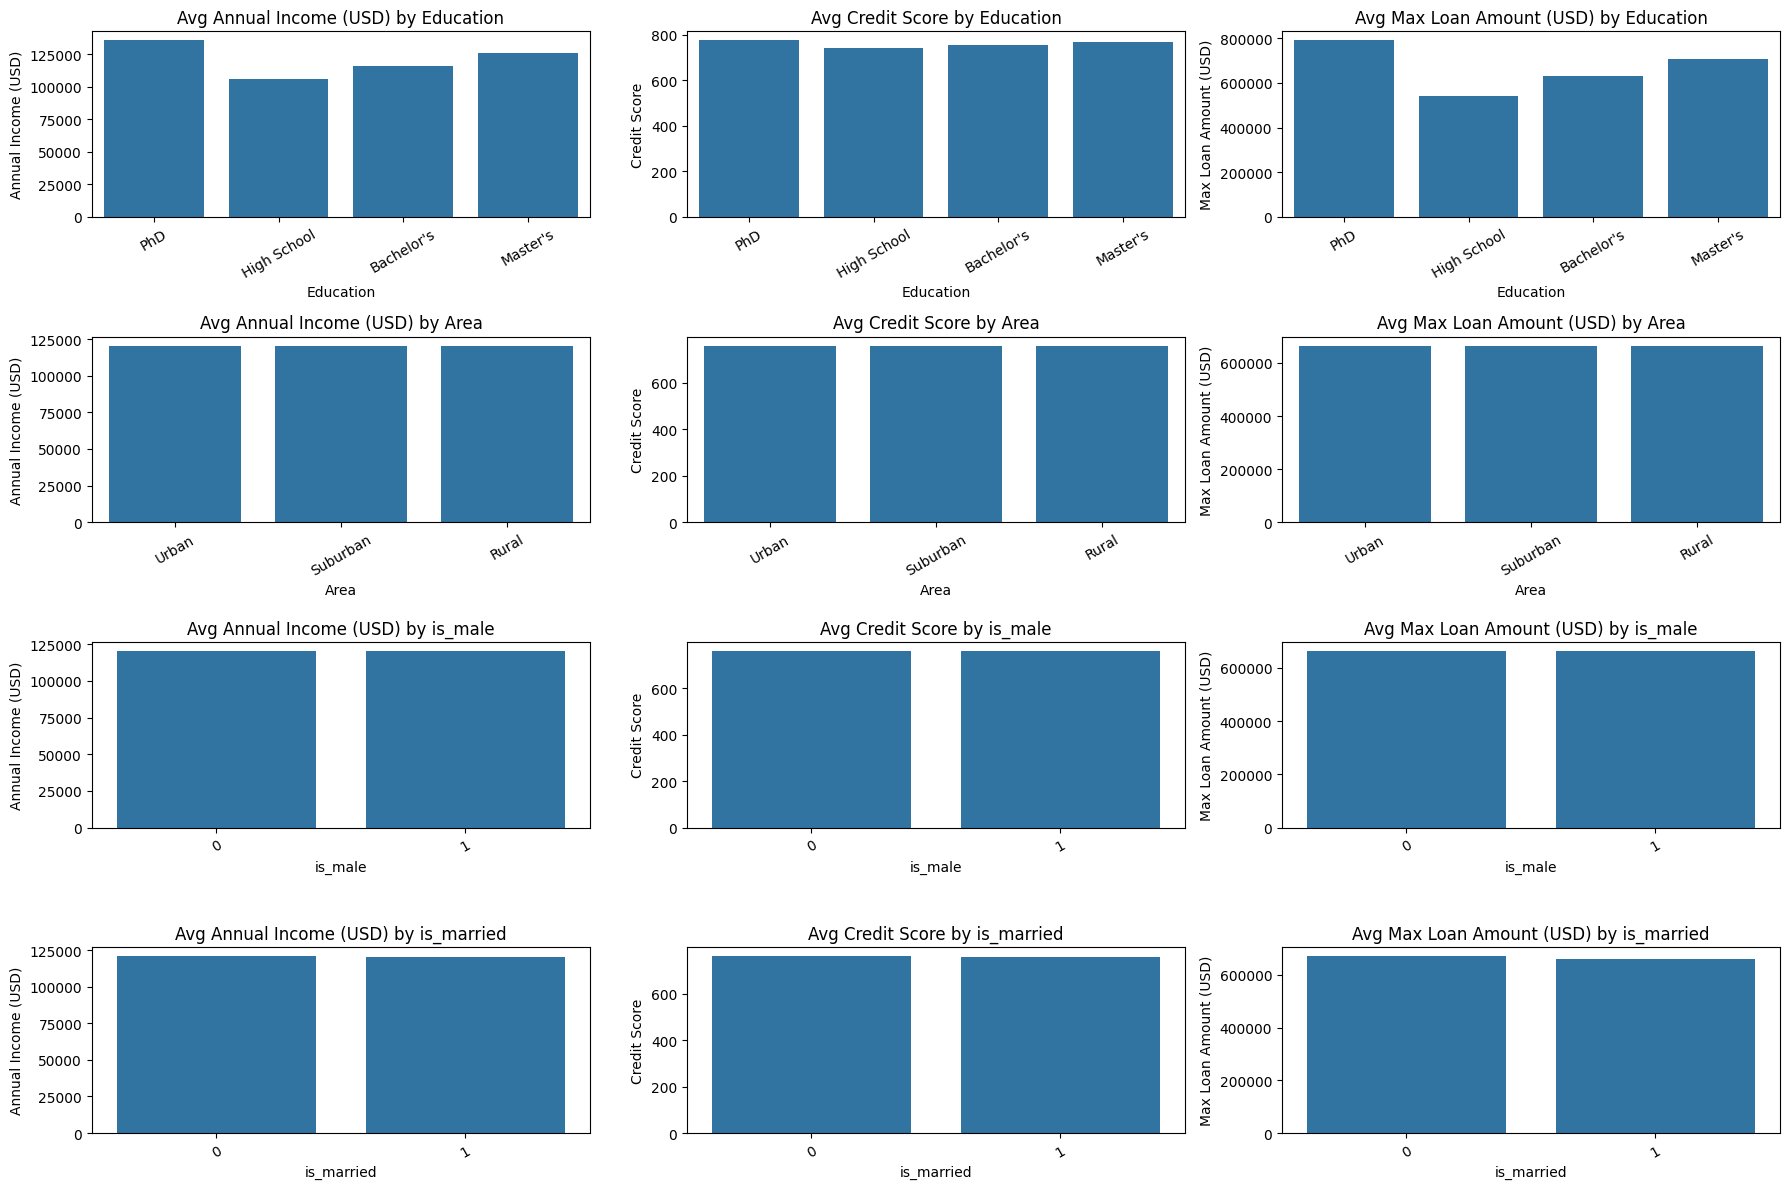

In [29]:
focus_cats = ['Education', 'Area', 'is_male', 'is_married']
focus_nums = ['Annual Income (USD)', 'Credit Score', 'Max Loan Amount (USD)']

fig, axes = plt.subplots(
    len(focus_cats),
    len(focus_nums),
    figsize=(18, 12)
)

for i, cat in enumerate(focus_cats):
    for j, num in enumerate(focus_nums):
        sns.barplot(
            data=df,
            x=cat,
            y=num,
            estimator=np.mean,
            errorbar=None,
            ax=axes[i, j]
        )
        axes[i, j].set_title(f"Avg {num} by {cat}")
        axes[i, j].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 3.3 Multivariate Analysis

#### (a) Pairplot with Hue

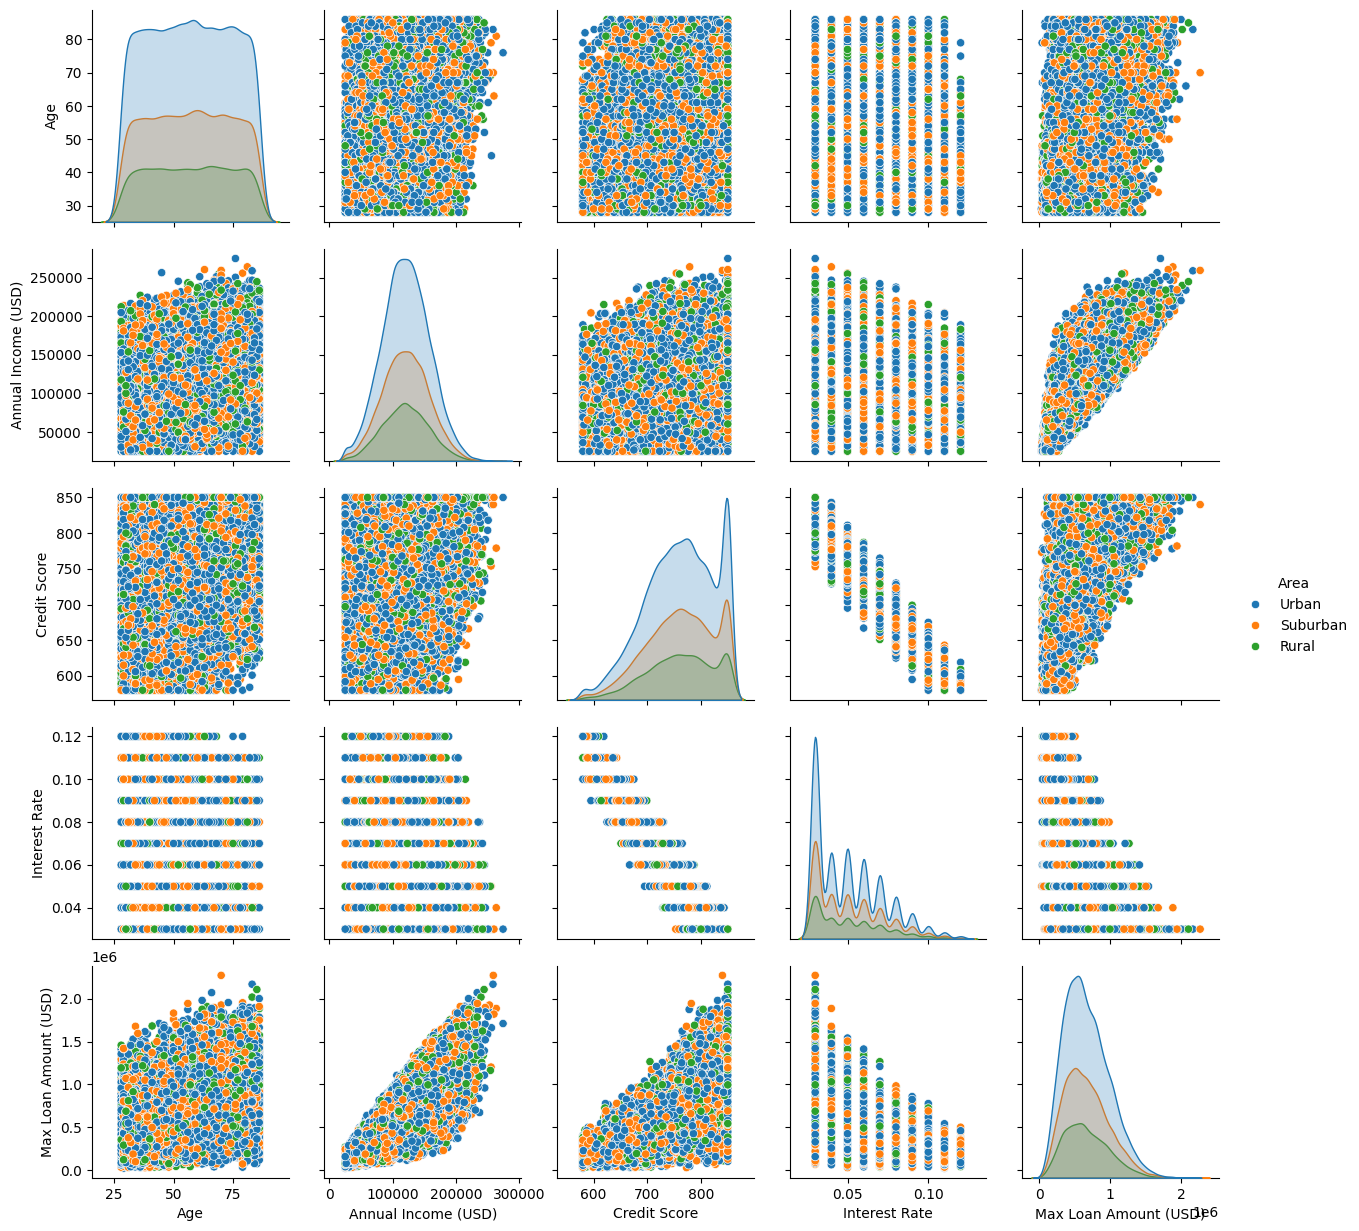

In [30]:
selected = [
    'Age',
    'Annual Income (USD)',
    'Credit Score',
    'Interest Rate',
    'Max Loan Amount (USD)'
]

sns.pairplot(df,
             vars=selected,
             hue='Area',
             diag_kind='kde')

plt.show()

#### (b) Bubble Plot

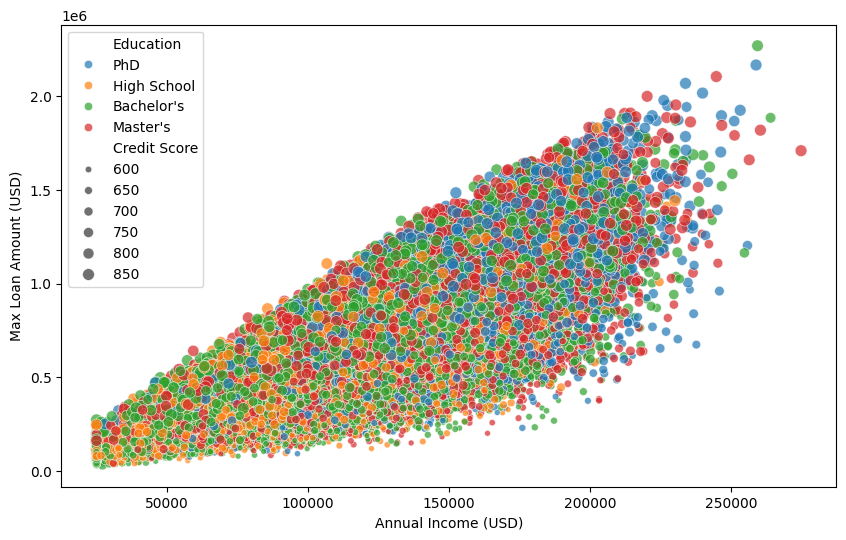

In [31]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Annual Income (USD)',
    y='Max Loan Amount (USD)',
    size='Credit Score',
    hue='Education',
    alpha=0.7
)

plt.show()

# 4. Feature Transformation

In [32]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split

In [33]:
from scipy import stats
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
z_scores = np.abs(stats.zscore(df[num_cols], nan_policy='omit'))
outliers = (z_scores > 3).sum()
print(outliers)

1298


Count outliers per column

In [34]:
from scipy.stats import zscore

# Compute Z-scores
z_scores = df[num_cols].apply(zscore)


outlier_count = (np.abs(z_scores) > 3).sum().sort_values(ascending=False)

print(outlier_count)

Down Payment (USD)             388
Max Loan Amount (USD)          244
Existing Monthly Debt (USD)    239
Interest Rate                  193
Loans Repaid                   169
Annual Income (USD)             65
Age                              0
Employment Years                 0
Credit Score                     0
is_male                          0
is_married                       0
dtype: int64


## 4.1 Log Transformation

In [35]:
# Columns with noticeable right skew 
skew_cols = [
    "Annual Income (USD)",
    "Down Payment (USD)",
    "Existing Monthly Debt (USD)",
    "Loans Repaid",
    "Max Loan Amount (USD)"
]


# Apply log1p transformation safely
for col in skew_cols:
    df[col] = np.log1p(df[col])

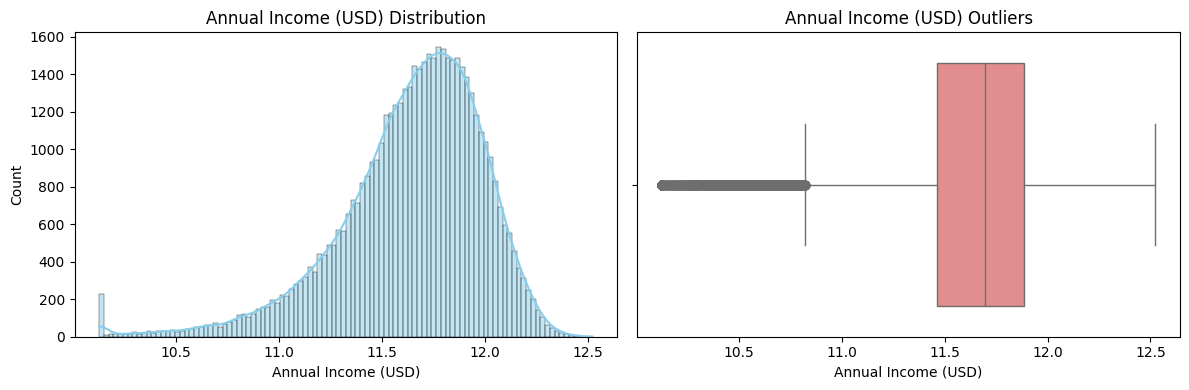

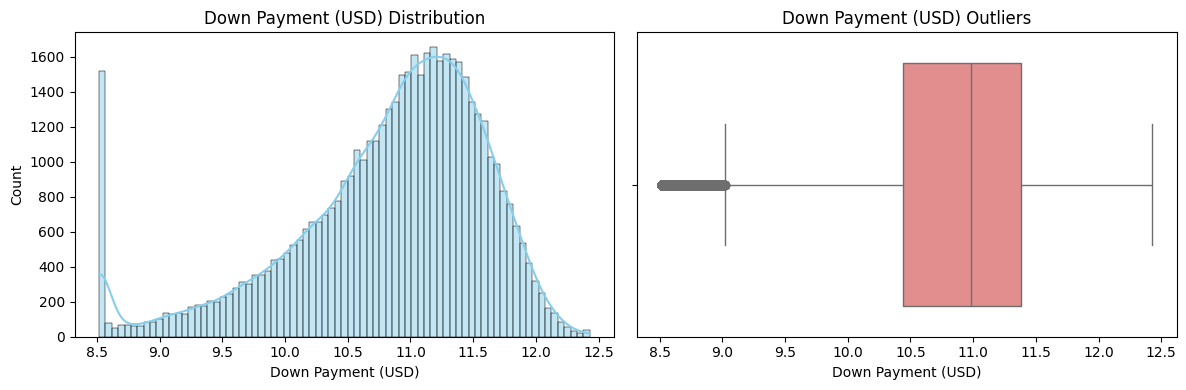

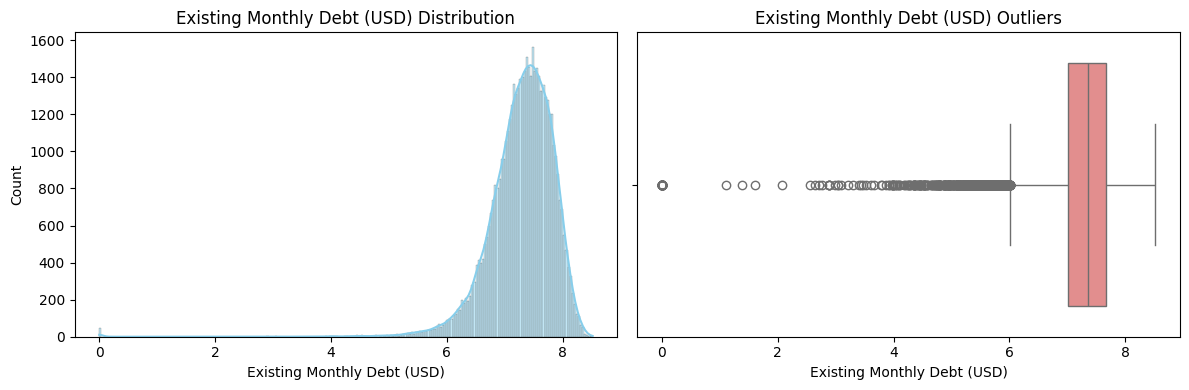

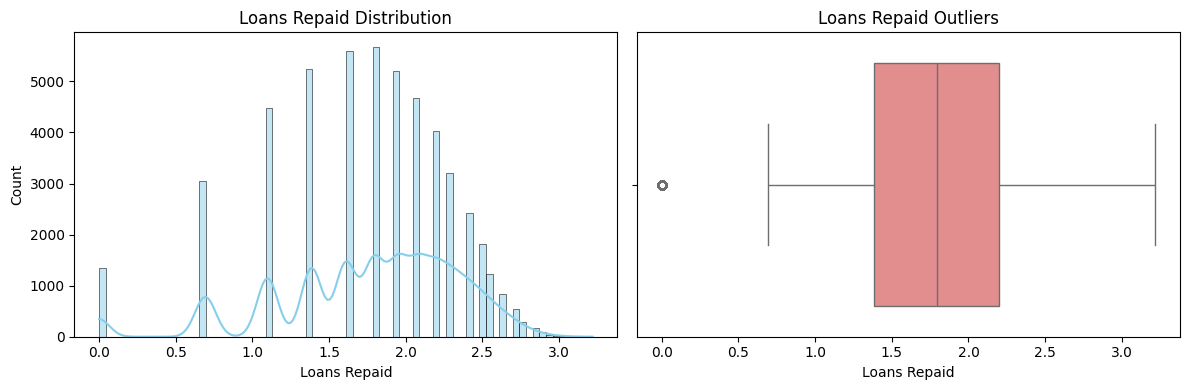

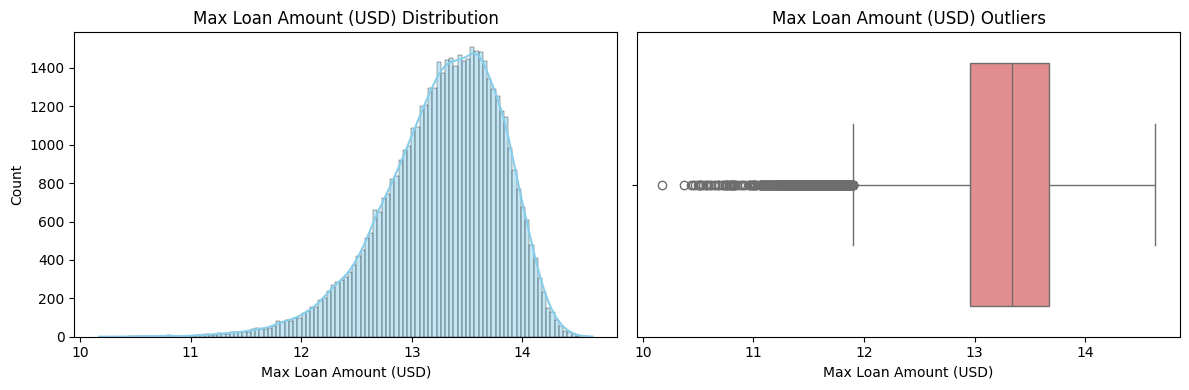

In [36]:
# Plot Histograms and Boxplots side-by-side for each numerical column
for col in skew_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram with KDE curve
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{col} Distribution')
    
    # Boxplot for outliers
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'{col} Outliers')
    
    plt.tight_layout()
    plt.show()

## 4.2 One-Hot Encoding

In [37]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

Splitting Data before Feature scaling

In [38]:
X = df.drop('Max Loan Amount (USD)', axis=1)
y = df['Max Loan Amount (USD)']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 4.3 Standard Scaling

In [40]:
# Implement StandardScaler to eliminate scaling bias across numerical features.

all_numeric_cols  = X_train.select_dtypes(include='number').columns # keep only non-binary numeric columns and scale them

cols_to_scale  = [c for c in all_numeric_cols  if df[c].nunique() > 2]

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform ONLY if using fit_transform so X_test uses it's own mean value
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [41]:
X_train = pd.DataFrame(X_train)
X_train.head(2)

,Age,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Loans Repaid,is_male,is_married,...,Job_Engineer,Job_Freelancer,Job_Lawyer,Job_Nurse,Job_Retired,Job_Sales Manager,Job_Software Engineer,Job_Teacher,Area_Suburban,Area_Urban
20512,1.358402,1.185590,1.283292,-1.007829,-0.021323,1.416239,1.058384,1.061433,0,0,...,False,True,False,False,False,False,False,False,False,True
21671,-1.063294,-1.123651,0.436010,-0.046650,-0.484636,-0.146647,0.188181,-0.272664,0,1,...,False,False,False,False,False,False,True,False,True,False


In [42]:
df.shape

(49990, 27)

# 5. Machine Learning and Hyperparameter Tuning

In [43]:
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score

# Linear Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Tree-Based Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Boosting Models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [44]:
models = {

    # ============================
    # Linear Models (Baseline)
    # ============================
    "Linear Regression": LinearRegression(
        n_jobs=-1
    ),

    "Ridge Regression": Ridge(),

    "Lasso Regression": Lasso(),

    "ElasticNet Regression": ElasticNet(),

    # ============================
    # Tree-Based Models
    # ============================
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),

    # ============================
    # Boosting Models
    # ============================
    "XGBoost": XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        tree_method='hist'
    ),

    "LightGBM": LGBMRegressor(
        random_state=42,
        force_col_wise=True,
        verbose=-1
    )
}

In [45]:
param_grids = {

    # ============================
    # Linear Models
    # ============================
    "Linear Regression": {},

    "Ridge Regression": {
        "alpha": [0.01, 0.1, 1, 10, 100]
    },

    "Lasso Regression": {
        "alpha": [0.001, 0.01, 0.1, 1, 10]
    },

    "ElasticNet Regression": {
        "alpha": [0.001, 0.01, 0.1, 1],
        "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    },

    # ============================
    # Tree-Based Models
    # ============================
    "Decision Tree": {
        "max_depth": [3, 5, 7, 10, 15, None],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 5, 10],
        "criterion": ["squared_error", "friedman_mse"]
    },

    "Random Forest": {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"]
    },

    # ============================
    # Boosting Models 
    # ============================
    "XGBoost": {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [3, 4, 5, 6, 7],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.6, 0.7, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
        "gamma": [0, 0.1, 0.2]
    },

    "LightGBM": {
        "n_estimators": [100, 200, 300, 500],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "num_leaves": [15, 31, 50, 70],
        "max_depth": [-1, 3, 5, 7, 10],
        "min_child_samples": [5, 10, 20, 30],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0]
    }
}

In [46]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [47]:
best_model = None
best_score = -float("inf")
best_model_name = ""

results = {}

for name, model in models.items():
    
    print(f"\nRunning RandomizedSearchCV for {name}...")
    
    random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grids[name],
    cv=kf,
    scoring='r2',
    n_jobs=1,
    n_iter=20 if model == "LightGBM" else 50,
    random_state=42
    )

    random_search.fit(X_train, y_train)

    results[name] = {
        "Best Params": random_search.best_params_,
        "Best CV Score (R2)": random_search.best_score_
    }

    print(name)
    print("Best Params:", random_search.best_params_)
    print("Best CV Score (R2):", random_search.best_score_)

    # STORE ONLY BEST MODEL
    if random_search.best_score_ > best_score:
        best_score = random_search.best_score_
        best_model = random_search.best_estimator_
        best_model_name = name



Running GridSearchCV for Linear Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=50. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Linear Regression
Best Params: {}
Best CV Score (R2): 0.9673628196271549

Running GridSearchCV for Ridge Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=50. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Ridge Regression
Best Params: {'alpha': 10}
Best CV Score (R2): 0.9673632229269641

Running GridSearchCV for Lasso Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=50. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Lasso Regression
Best Params: {'alpha': 0.001}
Best CV Score (R2): 0.9673290231556917

Running GridSearchCV for ElasticNet Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 20 is smaller than n_iter=50. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


ElasticNet Regression
Best Params: {'l1_ratio': 0.1, 'alpha': 0.001}
Best CV Score (R2): 0.9673624572434635

Running GridSearchCV for Decision Tree...
Decision Tree
Best Params: {'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': None, 'criterion': 'squared_error'}
Best CV Score (R2): 0.9804985739781815

Running GridSearchCV for Random Forest...
Random Forest
Best Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Best CV Score (R2): 0.959799407546325

Running GridSearchCV for XGBoost...
XGBoost
Best Params: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}
Best CV Score (R2): 0.995603877264274

Running GridSearchCV for LightGBM...
LightGBM
Best Params: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV Score (R2): 0.9960961501433259


In [48]:
# DataFram of results to make it more readable
results_df = pd.DataFrame(results).T
results_df.sort_values(by="Best CV Score (R2)", ascending=False)

,Best Params,Best CV Score (R2)
LightGBM,"{'subsample': 0.8, 'num_leaves': 31, 'n_estima...",0.996096
XGBoost,"{'subsample': 0.7, 'n_estimators': 500, 'max_d...",0.995604
Decision Tree,"{'min_samples_split': 10, 'min_samples_leaf': ...",0.980499
Ridge Regression,{'alpha': 10},0.967363
Linear Regression,{},0.967363
ElasticNet Regression,"{'l1_ratio': 0.1, 'alpha': 0.001}",0.967362
Lasso Regression,{'alpha': 0.001},0.967329
Random Forest,"{'n_estimators': 300, 'min_samples_split': 2, ...",0.959799


In [49]:
print("Best Model:", best_model_name)
print("Best CV Score (R2):", best_score)

Best Model: LightGBM
Best CV Score (R2): 0.9960961501433259


In [50]:
y_pred = best_model.predict(X_test)

In [51]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.024562763598971398
RMSE: 0.03407109536073247
R2 Score: 0.9959057765216079
